# Mod6L5 Data Challenge — Interpreting SLR Output (Dec 2023 NYC Taxi)


**Format:** We Do (Instructor prompts) → You Do (Student work) → We Share (reflection)


**Goal:** Choose **one** dependent variable (**Y**) from the taxi dataset and build **three** simple linear regressions (each with a different single **X**) on **Dec 2023** rides. For each model, interpret the **coefficient**, **intercept**, **p‑value**, and **R‑squared** in plain business language. Then decide which model is “better” *for decision‑making* and why.


> **Reminder:** No train/test split or advanced metrics today. We focus on reading `.summary()` and communicating results.

## Instructor Section (10 mins)

**Follow these steps/considerations as you work**


1) **Pick a useful Y.** Which outcome would someone actually act on?  Who is the stakeholder for your Y?

*Avoid constructing Y that bakes in your X (e.g., avoid using `fare_amount` as X when Y = `total_amount` which already includes fare).*


2) **Choose three X’s** you can know at decision time, and that plausibly relate to Y. 

*You may engineer a feature to use in the model if you like*

*Note:  SLR needs numeric only inputs so variables like `PULocationID` can't be used (categorical → not for SLR today unless you transform; stick to numeric X for this exercise)*


3) **Interpretation lenses:**
- **Units:** Always state slope in units (e.g., “per mile”, “per minute”).
- **p‑value:** Does evidence suggest the slope ≠ 0?
- **R²:** How much of Y’s variation is captured by this X? Does that help the decision?
- **Intercept:** Is X=0 meaningful? If not, say it’s a math anchor.
- **Plausibility:** Does the direction/size make sense (e.g., longer trip → higher fare)?


4) **Better ≠ only higher R².** Weigh **interpretability**, **actionability**, and **evidence** (p‑value, CI) alongside R².

## YOU DO (40 mins)

### Step 1: Read in the Data & Choose your **Y** (dependent variable)

Pick one from the 2023_Yellow_Taxi_Trip_Data_20251015 csv file  

In [115]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

df = pd.read_csv("../data/2023_Yellow_Taxi_Trip_Data_20251015.csv", low_memory=False)
display(df.head())
display(df.info())
display(df.describe())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,12/01/2023 04:11:39 PM,12/01/2023 04:19:13 PM,2.0,0.69,1.0,N,141,140,1,7.9,2.5,0.5,3,0.0,1.0,17.4,2.5,0.0
1,1,12/01/2023 04:11:39 PM,12/01/2023 04:20:41 PM,3.0,1.1,1.0,N,236,263,2,10,5.0,0.5,0,0.0,1.0,16.5,2.5,0.0
2,2,12/01/2023 04:11:39 PM,12/01/2023 04:20:38 PM,1.0,1.57,1.0,N,48,239,4,-10.7,-2.5,-0.5,0,0.0,-1.0,-17.2,-2.5,0.0
3,2,12/01/2023 04:11:39 PM,12/01/2023 04:20:38 PM,1.0,1.57,1.0,N,48,239,4,10.7,2.5,0.5,0,0.0,1.0,17.2,2.5,0.0
4,1,12/01/2023 04:11:39 PM,12/01/2023 04:34:39 PM,2.0,3,1.0,N,164,211,1,21.9,5.0,0.5,3,0.0,1.0,31.4,2.5,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3310907 entries, 0 to 3310906
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          object 
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            object 
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             object 
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           object 
 17  congestion_surcharge   float64
 18  airport_fee            float64
dtypes: float64(8), int64(4), object(7)
memory usage: 479.9+ MB


None

,VendorID,passenger_count,RatecodeID,PULocationID,DOLocationID,payment_type,extra,mta_tax,tolls_amount,improvement_surcharge,congestion_surcharge,airport_fee
count,3.310907e+06,3.133527e+06,3.133527e+06,3.310907e+06,3.310907e+06,3.310907e+06,3.310907e+06,3.310907e+06,3.310907e+06,3.310907e+06,3.133527e+06,3.133527e+06
mean,1.750368e+00,1.409560e+00,1.784972e+00,1.650685e+02,1.639182e+02,1.168633e+00,1.485240e+00,4.828656e-01,5.734011e-01,9.758456e-01,2.270032e+00,1.367974e-01
std,4.356449e-01,9.117169e-01,8.283274e+00,6.428330e+01,6.968454e+01,5.959677e-01,1.814139e+00,1.206643e-01,2.228458e+00,2.170912e-01,8.078364e-01,4.796868e-01
min,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-3.917000e+01,-5.000000e-01,-7.000000e+01,-1.000000e+00,-2.500000e+00,-1.750000e+00
25%,1.000000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.000000e+00,2.500000e+00,0.000000e+00
50%,2.000000e+00,1.000000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.000000e+00,5.000000e-01,0.000000e+00,1.000000e+00,2.500000e+00,0.000000e+00
75%,2.000000e+00,2.000000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.500000e+00,5.000000e-01,0.000000e+00,1.000000e+00,2.500000e+00,0.000000e+00
max,6.000000e+00,9.000000e+00,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,5.168000e+01,4.217000e+01,1.613800e+02,1.000000e+00,2.500000e+00,1.750000e+00


In [116]:
# Coerce fare, tip, distance to numeric safely
num_cols = ['fare_amount', 'tip_amount', 'extra','trip_distance']
for c in num_cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
)
# Clean data some and add a new column called 'tip_pct' as the target 
df = df[(df['fare_amount'] > 0) & (df['tip_amount'] >= 0) & (df['extra'] >= 0) & (df['trip_distance'] > 0)]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=num_cols)
df['tip_pct'] = (df['tip_amount']/df['fare_amount']).clip(0,1)

In [117]:
len(df)

3200243

In [118]:
df = df[df['extra'] <= df['extra'].quantile(0.9999)]
df = df[df['fare_amount'] <= df['fare_amount'].quantile(0.9999)]
df = df[df['tip_amount'] <= df['tip_amount'].quantile(0.9999)]
df = df[df['trip_distance'] <= df['trip_distance'].quantile(0.9999)]

In [119]:
df['trip_distance']

0           0.69
1           1.10
3           1.57
4           3.00
6           1.24
           ...  
3310901     0.71
3310902     1.70
3310903    21.60
3310905     0.01
3310906    16.67
Name: trip_distance, Length: 3199292, dtype: float64

### Step 2: Propose three candidate **X** predictors (numeric)

Pick three different X columns that are **numeric** and **known at decision time**.

In [120]:
Xone = sm.add_constant(df[['extra']])
Xtwo = sm.add_constant(df[['tip_pct']])
Xthree = sm.add_constant(df[['trip_distance']])

y = df['fare_amount']

### Step 3: Fit three one‑variable models with the SAME Y and different Xs

In [127]:
print('extra and fare_amount')
model = sm.OLS(y,Xone).fit()
display(model.summary())

print('tip_pct and fare_amount')
model = sm.OLS(y,Xtwo).fit()
display(model.summary())

print('trip_distance and fare_amount')
model = sm.OLS(y,Xthree).fit()
display(model.summary())

extra and fare_amount


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            fare_amount   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                 8.548e+04
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:04:26   Log-Likelihood:            -1.3604e+07
No. Observations:             3199292   AIC:                         2.721e+07
Df Residuals:                 3199290   BIC:                         2.721e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.5666      0.012   1406.465      0.000      17.542      17.591
extra          1.5420      0.005    292.375      0.000       1.532       1.552
==============================================================================
Omnibus:                  1873558.283   Durbin-Watson:                   1.950
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         21197167.571
Skew:                           2.654   Prob(JB):                         0.00
Kurtosis:                      14.438   Cond. No.                         3.37
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

tip_pct and fare_amount


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            fare_amount   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                 9.783e+04
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:04:27   Log-Likelihood:            -1.3598e+07
No. Observations:             3199292   AIC:                         2.720e+07
Df Residuals:                 3199290   BIC:                         2.720e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.1704      0.017   1462.058      0.000      24.138      24.203
tip_pct      -21.1946      0.068   -312.776      0.000     -21.327     -21.062
==============================================================================
Omnibus:                  1815487.275   Durbin-Watson:                   1.969
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         18763465.234
Skew:                           2.579   Prob(JB):                         0.00
Kurtosis:                      13.684   Cond. No.                         7.43
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

trip_distance and fare_amount


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            fare_amount   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                 1.974e+07
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:04:27   Log-Likelihood:            -1.0495e+07
No. Observations:             3199292   AIC:                         2.099e+07
Df Residuals:                 3199290   BIC:                         2.099e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.6150      0.005   1676.805      0.000       7.606       7.624
trip_distance     3.6734      0.001   4443.171      0.000       3.672       3.675
==============================================================================
Omnibus:                  3220306.856   Durbin-Watson:                   1.884
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        597394011.433
Skew:                           4.561   Prob(JB):                         0.00
Kurtosis:                      69.319   Cond. No.                         7.02
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Step 4: Visual check for the “best” model candidate

Pick the model you currently prefer (based on business sense + evidence).
- Create a scatter of X vs. Y with the fitted line.

<Axes: xlabel='extra', ylabel='fare_amount'>

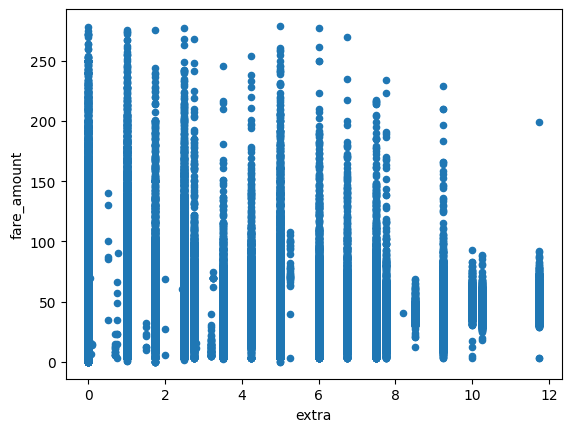

In [128]:
df.plot(kind = 'scatter',x='extra',y='fare_amount')

<Axes: xlabel='tip_pct', ylabel='fare_amount'>

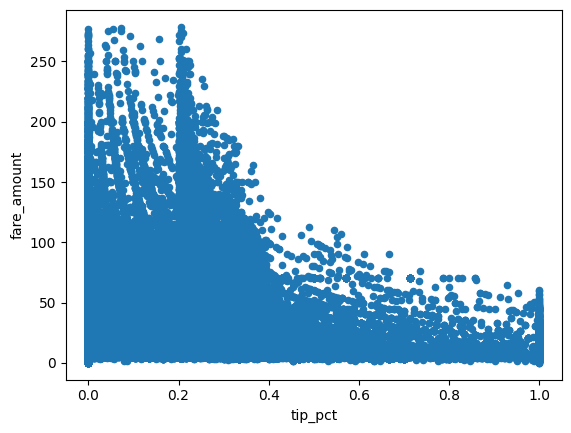

In [129]:
df.plot(kind = 'scatter',x='tip_pct',y='fare_amount')

<Axes: xlabel='trip_distance', ylabel='fare_amount'>

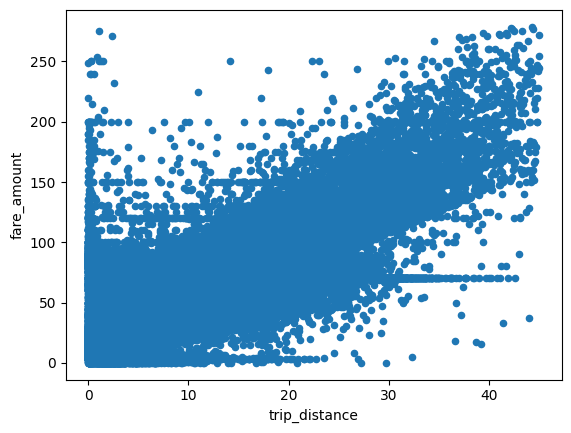

In [130]:
#very correlated because fare amount is calculated on trip_distance
#plt.regplot()
df.plot(kind = 'scatter',x='trip_distance',y='fare_amount')

### Step 5: Interpret Each Model (write in plain English)
Fill the three blocks below. Use **units** and **percentage points (pp)** where relevant.

- **Slope (β₁):** “For each +1 unit of X, Y changes by …”
- **Intercept (β₀):** meaningful or just a math anchor? Explain.
- **p‑value:** is there evidence the slope ≠ 0?
- **R²:** how much variation does this X explain?
- **Judgment:** is the effect size **practically** meaningful (tie to business)?

### Model A — Y = {{YOUR_Y}} ~ X2 = {{YOUR_X2}}
- Slope (β₁): Per dollar of extra fee, the fare amount increases by 1.5420.
- Intercept (β₀): If the passenger received no extra fee, we expect the driver to receive $17.56. This is meaningful as it would mean the driver makes more money as the are more extra fees, reasonably.
- p‑value (slope): Our P-Value is less than 0, so the relationship between extra fees and fare_amount is statistically significant.
- 95% CI for slope: We can say with 95% confidence that with each extra fee, the population of drivers would have a increase of fare amount by about 1.53 to 1.55 more dollars.
- R²: With our R squared only being 2.6%, we would say that the relationship between extra fees and fare amount is not very strong. Other factors are probably more influential to the fare amount than extra fees.
- Business readout (units): We were able to determine a statistically significant correlation between error amounts and fare amounts. For each error, the driver's fare amount increasees by 1.54. With that being said, we were able to determine that tip percentage was 2.6% related to fare_amount that if there were no error fees, they would get $17.56.
- One limitation: Our values for our extra column seem to be repeated constantly, as it shows lines of data on our scatterplot.

### Model B — Y = {{YOUR_Y}} ~ X2 = {{YOUR_X2}}
- Slope (β₁): For each unit of tip percentage increase, the fare amount decreases by 21.10.
- Intercept (β₀): If the driver received no tip, we expect $24.11. This is meaningful as it would mean the driver benefits off of no tip.
- p‑value (slope): As our P-Value is less than 0, we can stay that our determination is statistically significant.
- 95% CI for slope: We can say with 95% confidence that with each percentage of tip, the population of drivers would have a decrease of fare amount by about -21.24 to -20.98 less dollars.
- R²: There is a 3% relationship between tip percentage and fare amount.
- Business readout (units): We were able to determine a statistically significant correlation between fare amount and tip percentage. For each unit of tip percentage increase, the driver's fare amount decreases by 21.10. With that being said, we were able to determine that tip percentage was 3% related to fare_amount and when drivers aren't tipped, they would get $24.11.
- One limitation: As our R squared is very low, there could be other factors that impact the fare amount more than our tip percentage.

### Model C — Y = {{YOUR_Y}} ~ X3 = {{YOUR_X3}}
- Slope (β₁): For every mile traveled, the fare amount increases by 3.67.
- Intercept (β₀): … In a hypothetical ride where there were 0 miles, the driver would get 7.61 dollars.
- p‑value (slope): Our P-Value is less than 0, so the relationship between trip_distance and fare_amount is statistically significant.
- 95% CI for slope: We can say with 95% confidence, that our average increase in fare amount per mile traveled would be within 3.672 and 3.675.
- R²: With an R squared of 86.1%, we can say the relationship between trip distance and fair amount is very strong. Compared to the other tests we've done, this has the highest relationship between X and Y.
- Business readout (units): We were able to determine a statistically significant correlation between trip distance and fair amount. For each mile traveled, the driver's fare amount increases by 3.67. We were also able to determine that tip percentage was 86.1% related to fare_amount.
- One limitation: This is obvious as fare_amount is derived from trip_distance, as the calculation for fare_amount must use trip_distance.

Of all three models, our most practically meaningful was our Model C, which showed the relationship between trip distance and fare amount. For cab drivers, although it might be obvious to know there is a significance between trip distance and fare amount, we were able to confirm that assumption using the model.

## We Share (10 mins) — Reflection & Decision (write 1-2 short paragraphs)

1) **Which model is “better” for a stakeholder decision and why?**
- Weigh **evidence** (p‑value, CI), **explanatory power** (R²), **interpretability**, and **business impact** (units, MDE if relevant).
2) **What would you do next week to strengthen trust in this model?**
- (Preview) time‑based validation, hold‑out testing, segment checks, adding more plausible X’s, checking assumptions.